In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../dataset/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df.shape

(918, 12)

In [7]:
df.info()
df.describe()
df.columns
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

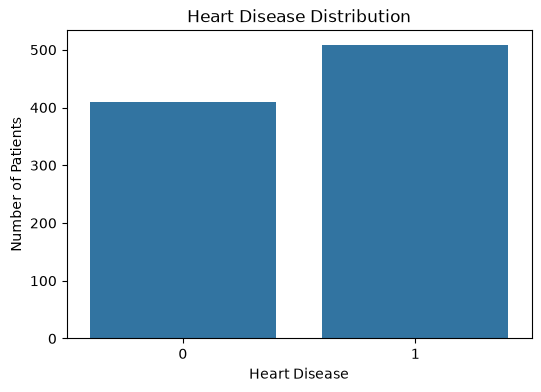

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='HeartDisease', data=df)

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')

plt.show()

In [13]:

data.select_dtypes(include='str').columns


Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in data.select_dtypes(include='str').columns:
    data[column] = label_encoder.fit_transform(data[column])

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [17]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

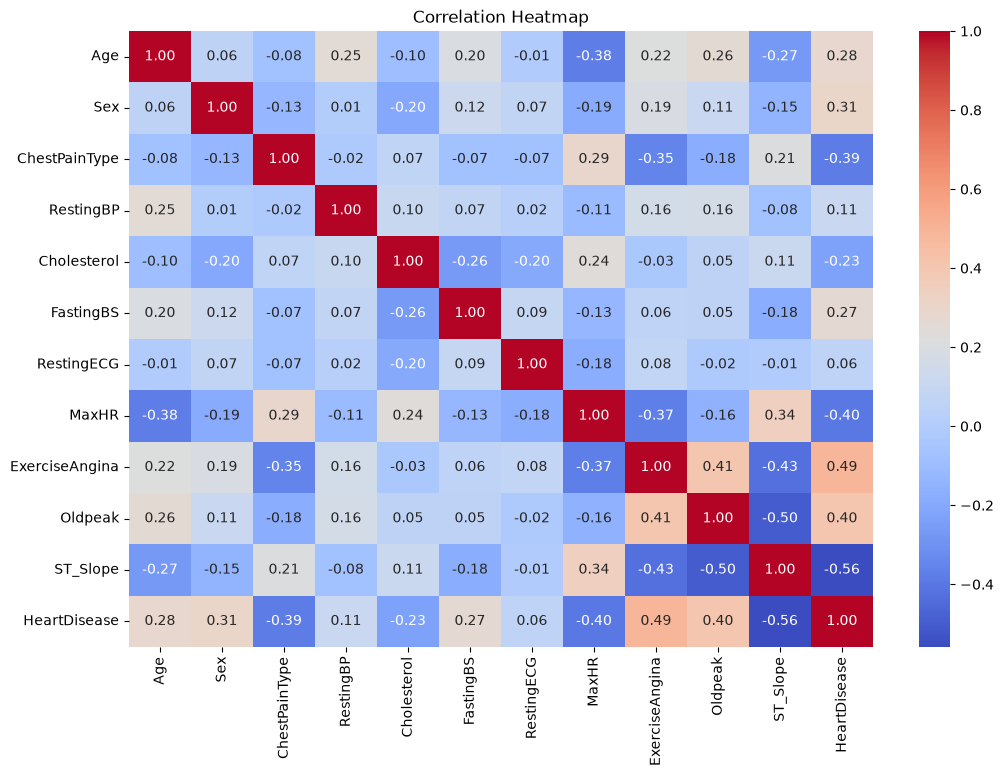

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [19]:
X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)


Features:
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='str')

Target:
HeartDisease


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (734, 11)
Testing data: (184, 11)


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)

In [23]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression
Accuracy : 0.8695652173913043
Precision: 0.8482142857142857
Recall   : 0.9313725490196079
F1 Score : 0.8878504672897196


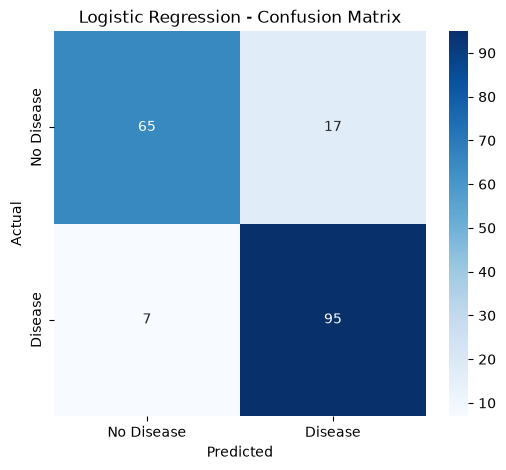

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [24]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

In [25]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Classifier")
print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Decision Tree Classifier
Accuracy : 0.7880434782608695
Precision: 0.8118811881188119
Recall   : 0.803921568627451
F1 Score : 0.8078817733990148


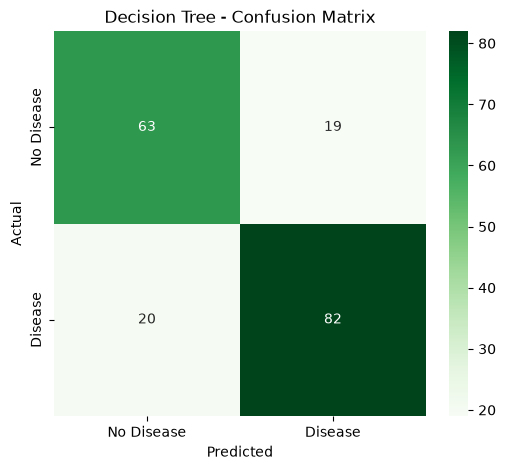

In [27]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [28]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

In [29]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Classifier")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Classifier
Accuracy : 0.875
Precision: 0.8761904761904762
Recall   : 0.9019607843137255
F1 Score : 0.8888888888888888


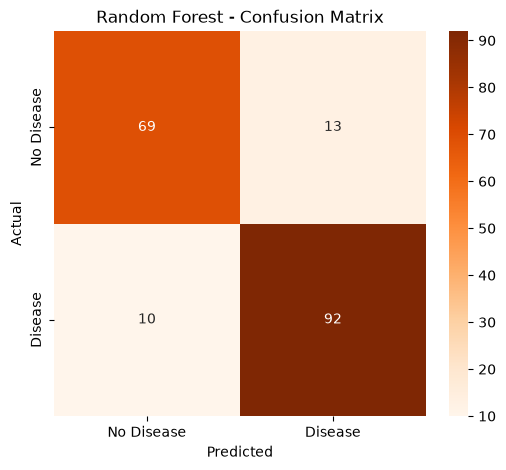

In [30]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [31]:
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    'Precision': [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    'Recall': [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    'F1 Score': [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

results

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.869565,0.848214,0.931373,0.887850
1,Decision Tree,0.788043,0.811881,0.803922,0.807882
2,Random Forest,0.875000,0.876190,0.901961,0.888889


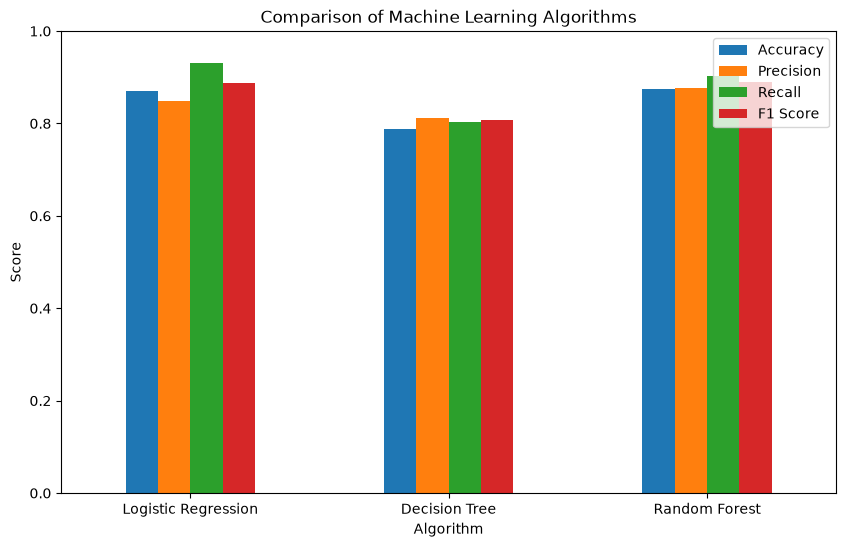

In [32]:
results.set_index('Algorithm').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparison of Machine Learning Algorithms')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.show()

In [33]:
best_algorithm = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Performing Algorithm:")
print(best_algorithm)

Best Performing Algorithm:
Algorithm    Random Forest
Accuracy             0.875
Precision          0.87619
Recall            0.901961
F1 Score          0.888889
Name: 2, dtype: object


In [34]:
best_accuracy = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Algorithm Based on Accuracy:")
print(best_accuracy)

Best Algorithm Based on Accuracy:
Algorithm    Random Forest
Accuracy             0.875
Precision          0.87619
Recall            0.901961
F1 Score          0.888889
Name: 2, dtype: object
